In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [4]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [5]:
sgpa_columns = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8"
]

df["Average_SGPA"] = df[sgpa_columns].mean(axis=1)

print("Average_SGPA created successfully.")
display(df[sgpa_columns + ["Average_SGPA"]].head())

Average_SGPA created successfully.


,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,Average_SGPA
0,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.18125
1,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.24625
2,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.51500
3,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.54125
4,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.61375


In [6]:
df["SGPA_Consistency"] = df[sgpa_columns].std(axis=1)

print("SGPA_Consistency created successfully.")
display(df[["Average_SGPA", "SGPA_Consistency"]].head())

SGPA_Consistency created successfully.


,Average_SGPA,SGPA_Consistency
0,6.18125,0.381480
1,5.24625,0.284250
2,5.51500,0.326890
3,7.54125,0.420457
4,8.61375,0.332864


In [7]:
skill_columns = [
    "AptitudeTestScore",
    "CodingTestScore",
    "SoftSkillsRating",
    "MockInterviewScore"
]

df["Overall_Skill_Score"] = df[skill_columns].mean(axis=1)

print("Overall_Skill_Score created successfully.")
display(df[skill_columns + ["Overall_Skill_Score"]].head())

Overall_Skill_Score created successfully.


,AptitudeTestScore,CodingTestScore,SoftSkillsRating,MockInterviewScore,Overall_Skill_Score
0,66.7,49.4,2.2,47.8,41.525
1,48.2,26.7,2.4,25.8,25.775
2,73.8,67.7,2.8,41.5,46.450
3,69.8,66.9,2.7,48.0,46.850
4,73.1,71.7,2.1,61.7,52.150


In [8]:
experience_columns = [
    "Internships",
    "Projects",
    "Certifications",
    "Publications",
    "Workshops"
]

df["Experience_Score"] = df[experience_columns].sum(axis=1)

print("Experience_Score created successfully.")
display(df[experience_columns + ["Experience_Score"]].head())

Experience_Score created successfully.


,Internships,Projects,Certifications,Publications,Workshops,Experience_Score
0,1,2,2,0,NaN,5.0
1,0,1,1,0,0.0,2.0
2,1,3,1,0,1.0,6.0
3,1,2,2,0,1.0,6.0
4,2,3,4,1,NaN,10.0


In [9]:
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "Average_SGPA",
    "Overall_Skill_Score",
    "Experience_Score"
]

scaler = MinMaxScaler()

df[["Academic_Score", "Skill_Score", "Experience_Normalized"]] = scaler.fit_transform(
    df[score_columns]
)

df["Placement_Readiness_Score"] = (
    0.4 * df["Academic_Score"] +
    0.4 * df["Skill_Score"] +
    0.2 * df["Experience_Normalized"]
)

print("Placement_Readiness_Score created successfully.")
display(
    df[
        [
            "Average_SGPA",
            "Overall_Skill_Score",
            "Experience_Score",
            "Placement_Readiness_Score"
        ]
    ].head()
)

Placement_Readiness_Score created successfully.


,Average_SGPA,Overall_Skill_Score,Experience_Score,Placement_Readiness_Score
0,6.18125,41.525,5.0,0.366707
1,5.24625,25.775,2.0,0.205823
2,5.51500,46.450,6.0,0.353795
3,7.54125,46.850,6.0,0.490535
4,8.61375,52.150,10.0,0.628425


In [10]:
new_features = [
    "Average_SGPA",
    "SGPA_Consistency",
    "Overall_Skill_Score",
    "Experience_Score",
    "Placement_Readiness_Score"
]

display(df[new_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Average_SGPA,50000.0,7.253136,1.553708,4.000000,6.085000,7.253750,8.430000,10.000000
SGPA_Consistency,50000.0,0.283144,0.094765,0.000000,0.224992,0.284577,0.345437,0.720058
Overall_Skill_Score,49998.0,46.065814,13.560885,1.500000,38.300000,45.600000,57.000000,98.100000
Experience_Score,50000.0,7.546640,4.056402,0.000000,5.000000,7.000000,11.000000,18.000000
Placement_Readiness_Score,49998.0,0.485262,0.181673,0.058458,0.359070,0.484753,0.633742,0.946659


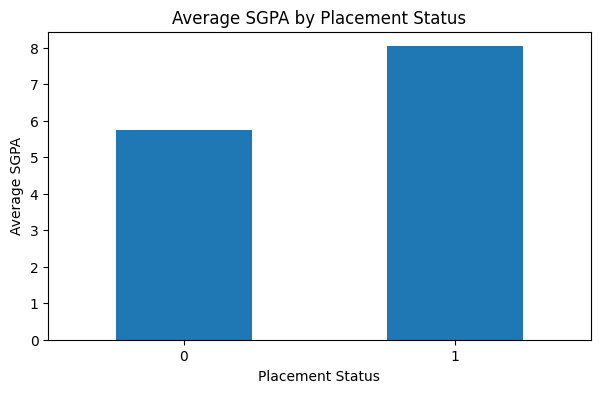

In [11]:
plt.figure(figsize=(7, 4))

df.groupby("PlacementStatus")["Average_SGPA"].mean().plot(kind="bar")

plt.title("Average SGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average SGPA")
plt.xticks(rotation=0)
plt.show()

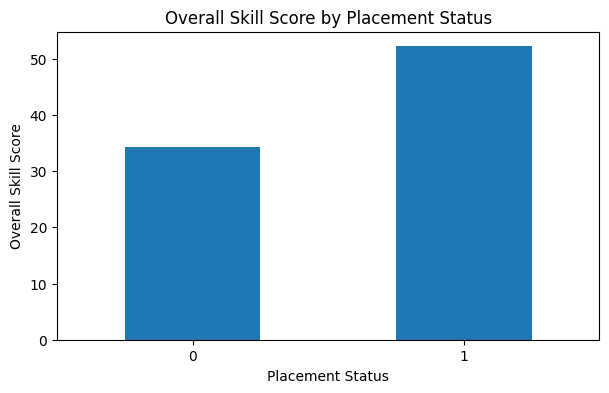

In [12]:
plt.figure(figsize=(7, 4))

df.groupby("PlacementStatus")["Overall_Skill_Score"].mean().plot(kind="bar")

plt.title("Overall Skill Score by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Overall Skill Score")
plt.xticks(rotation=0)
plt.show()

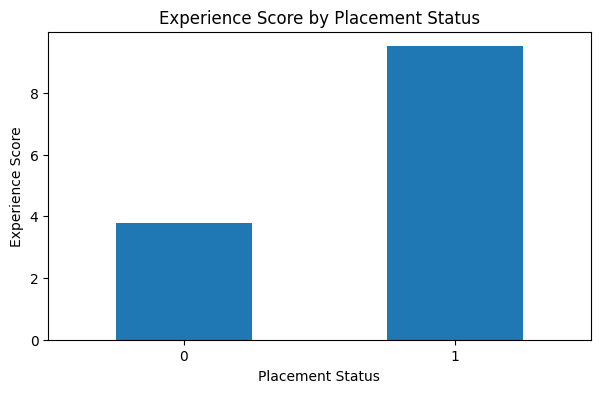

In [13]:
plt.figure(figsize=(7, 4))

df.groupby("PlacementStatus")["Experience_Score"].mean().plot(kind="bar")

plt.title("Experience Score by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Experience Score")
plt.xticks(rotation=0)
plt.show()

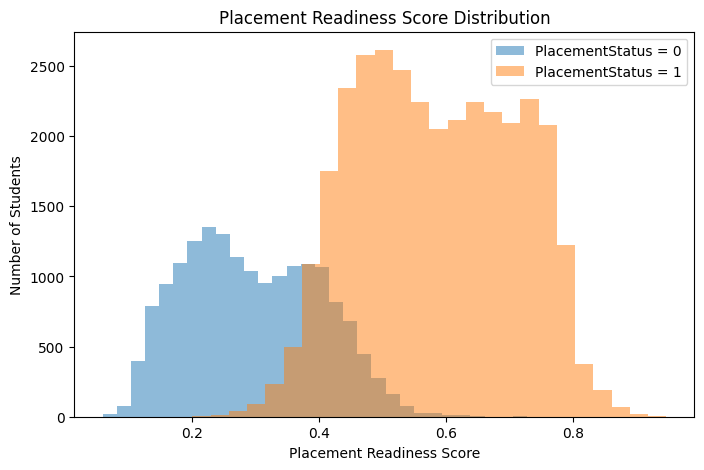

In [14]:
plt.figure(figsize=(8, 5))

for status in sorted(df["PlacementStatus"].dropna().unique()):
    values = df.loc[df["PlacementStatus"] == status, "Placement_Readiness_Score"]
    plt.hist(values, bins=30, alpha=0.5, label=f"PlacementStatus = {status}")

plt.xlabel("Placement Readiness Score")
plt.ylabel("Number of Students")
plt.title("Placement Readiness Score Distribution")
plt.legend()
plt.show()

In [15]:
correlation_data = df[
    new_features + ["PlacementStatus"]
].corr()["PlacementStatus"].sort_values(ascending=False)

display(correlation_data)

,PlacementStatus
PlacementStatus,1.000000
Placement_Readiness_Score,0.758050
Average_SGPA,0.697902
Experience_Score,0.670554
Overall_Skill_Score,0.626933
SGPA_Consistency,-0.036661


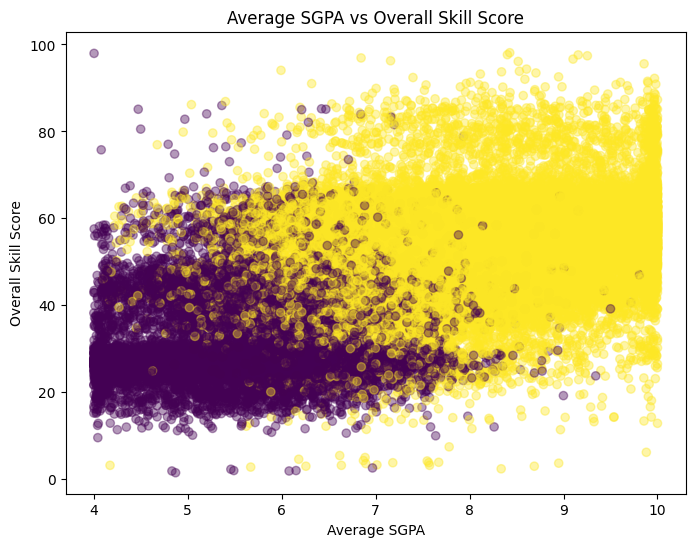

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Average_SGPA"],
    df["Overall_Skill_Score"],
    c=df["PlacementStatus"],
    alpha=0.4
)

plt.xlabel("Average SGPA")
plt.ylabel("Overall Skill Score")
plt.title("Average SGPA vs Overall Skill Score")
plt.show()

In [17]:
print("Missing Values in New Features:")

display(
    df[new_features].isnull().sum()
)

Missing Values in New Features:


,0
Average_SGPA,0
SGPA_Consistency,0
Overall_Skill_Score,2
Experience_Score,0
Placement_Readiness_Score,2


In [18]:
output_file = "placement_predict_50k_feature_engineered.csv"

df.to_csv(output_file, index=False)

print("Feature-engineered dataset saved as:", output_file)

Feature-engineered dataset saved as: placement_predict_50k_feature_engineered.csv


In [19]:
files.download("placement_predict_50k_feature_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
print("""
SESSION 3 — FEATURE ENGINEERING AND EDA SUMMARY

1. Loaded the placement prediction dataset.
2. Created Average_SGPA from eight semester SGPA values.
3. Created SGPA_Consistency to measure academic variation.
4. Created Overall_Skill_Score from aptitude, coding,
   soft skills and mock interview scores.
5. Created Experience_Score from internships, projects,
   certifications, publications and workshops.
6. Created Placement_Readiness_Score using academic,
   skill and experience components.
7. Performed EDA on the engineered features.
8. Compared engineered features across placement groups.
9. Examined correlations with PlacementStatus.
10. Exported the feature-engineered dataset.
""")


SESSION 3 — FEATURE ENGINEERING AND EDA SUMMARY

1. Loaded the placement prediction dataset.
2. Created Average_SGPA from eight semester SGPA values.
3. Created SGPA_Consistency to measure academic variation.
4. Created Overall_Skill_Score from aptitude, coding,
   soft skills and mock interview scores.
5. Created Experience_Score from internships, projects,
   certifications, publications and workshops.
6. Created Placement_Readiness_Score using academic,
   skill and experience components.
7. Performed EDA on the engineered features.
8. Compared engineered features across placement groups.
9. Examined correlations with PlacementStatus.
10. Exported the feature-engineered dataset.

